# PCB Binary Classifier - EfficientNet-B0


## 1. Imports

In [2]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
from tensorflow import data as tf_data
from tensorflow import lite
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("TF version:", tf.__version__)
print("Keras version:", keras.__version__)

2026-04-02 14:37:15.052254: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775140635.375483      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775140635.471266      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775140636.261828      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775140636.261884      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775140636.261887      55 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
Keras version: 3.10.0


## 2. Config

In [5]:
INPUT_SIZE  = 96      
BATCH_SIZE  = 32
EPOCHS_TOP  = 10       
EPOCHS_FINE = 10      
CLASS_NUM   = 2
LABELS      = ["not_pcb", "pcb"]  

TRAIN_DIR    = "/kaggle/working/balanced/train"
VALIDATE_DIR = "/kaggle/working/balanced/validate"
TEST_DIR     = "/kaggle/working/balanced/test"

## 3. Rebalance Dataset

In [6]:
val_pcb = "/kaggle/input/datasets/hassenalrubei/weee-extrapcb/validate/pcb"
val_not_pcb = "/kaggle/input/datasets/hassenalrubei/weee-extrapcb/validate/not_pcb"

pcb_count = len(os.listdir(val_pcb))  # whatever is actually there
files = os.listdir(val_not_pcb)
random.seed(42)
keep = set(random.sample(files, pcb_count))  # match actual PCB count

for split in ["train", "validate", "test"]:
    for cls in ["pcb", "not_pcb"]:
    src = f"/kaggle/input/datasets/hassenalrubei/weee-extrapcb/{split}/{cls}"
    dst = f"/kaggle/working/balanced/{split}/{cls}"
    os.makedirs(dst, exist_ok=True)
    for f in os.listdir(src):
        if split == "validate" and cls == "not_pcb" and f not in keep:
            continue
        shutil.copy(os.path.join(src, f), dst)

for split in ["train", "validate", "test"]:
    path = f"/kaggle/working/balanced/{split}"
    counts = {c: len(os.listdir(os.path.join(path, c))) for c in os.listdir(path)}
    print(f"{split}: {counts}")

train: {'pcb': 857, 'not_pcb': 1116}
validate: {'pcb': 61, 'not_pcb': 61}
test: {'pcb': 111, 'not_pcb': 240}


## 4. Data Augmentation & Loading

Normalisation uses `img / 127.5 - 1` to map pixels to `[-1, 1]`, which is what MobileNetV2 expects.

In [7]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

def load_ds(path, augment=False, shuffle=False):
    ds = keras.utils.image_dataset_from_directory(
        path,
        validation_split=None,
        seed=1337,
        shuffle=shuffle,
        image_size=(INPUT_SIZE, INPUT_SIZE),
        batch_size=BATCH_SIZE,
        label_mode="categorical",
        class_names=LABELS,
    )
    if augment:
        ds = ds.map(
            lambda img, label: (data_augmentation(img), label),
            num_parallel_calls=tf_data.AUTOTUNE,
        )
    else:
        ds = ds.map(
            lambda img, label: (img, label),
            num_parallel_calls=tf_data.AUTOTUNE,
        )
    return ds.prefetch(tf_data.AUTOTUNE)

train_ds    = load_ds(TRAIN_DIR,    augment=True,  shuffle=True)
validate_ds = load_ds(VALIDATE_DIR, augment=False, shuffle=False)
test_ds     = load_ds(TEST_DIR,     augment=False, shuffle=False)

print("Classes:", LABELS)

Found 1973 files belonging to 2 classes.


2026-04-02 14:38:11.773302: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 122 files belonging to 2 classes.
Found 351 files belonging to 2 classes.
Classes: ['not_pcb', 'pcb']


## 5. Build Model

`alpha=0.35` keeps the model small enough for the H7 Plus.
The base is frozen initially; we only train the classifier head first.

In [8]:
def build_model():
    input_shape = (INPUT_SIZE, INPUT_SIZE, 3)
    inputs = layers.Input(shape=input_shape)

    # EfficientNet expects [0, 255] — preprocessing is handled internally
    base = keras.applications.EfficientNetB0(
        include_top=False,
        input_shape=input_shape,
        input_tensor=inputs,
        weights="imagenet",
    )
    base.trainable = False

    x = layers.GlobalAveragePooling2D(name="avg_pool")(base.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(CLASS_NUM, activation="softmax")(x)

    return keras.Model(inputs, outputs)

model = build_model()
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 96, 96, 3) │          0 │ input_layer[0][0] │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 96, 96, 3) │          7 │ rescaling[0][0]   │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 96, 96, 3) │          0 │ normalization[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 97, 97, 3) │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 48, 48,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 48, 48,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 48, 48,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 48, 48,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 48, 48,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 48, 48,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 48, 48,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 48, 48,    │        512 │ block1a_se_excit

 Total params: 4,057,253 (15.48 MB)

 Trainable params: 5,122 (20.01 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 6. Phase 1 — Train Classifier Head

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    #keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
]

history_top = model.fit(
    train_ds,
    validation_data=validate_ds,
    epochs=EPOCHS_TOP,
    callbacks=callbacks,
)

Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 32s 320ms/step - accuracy: 0.6897 - loss: 0.6820 - val_accuracy: 0.9016 - val_loss: 0.2732 - learning_rate: 0.0010
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 16s 251ms/step - accuracy: 0.9163 - loss: 0.2139 - val_accuracy: 0.9508 - val_loss: 0.1992 - learning_rate: 0.0010
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 16s 253ms/step - accuracy: 0.9425 - loss: 0.1441 - val_accuracy: 0.9180 - val_loss: 0.2017 - learning_rate: 0.0010
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 16s 250ms/step - accuracy: 0.9385 - loss: 0.1508 - val_accuracy: 0.9508 - val_loss: 0.1905 - learning_rate: 0.0010
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 265ms/step - accuracy: 0.9532 - loss: 0.1254 - val_accuracy: 0.9508 - val_loss: 0.1996 - learning_rate: 0.0010
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 16s 257ms/step - accuracy: 0.9670 - loss: 0.0964 - val_accuracy: 0.9426 - val_loss: 0.2003 - learning_rate: 0.0010
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 16s 250ms/step - accuracy: 0.9555 - loss: 0.

## 8. Evaluate on Test Set

In [10]:
loss, acc = model.evaluate(test_ds)
print(f"Test accuracy: {acc:.2%}  |  Test loss: {loss:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 210ms/step - accuracy: 0.9702 - loss: 0.0907
Test accuracy: 95.73%  |  Test loss: 0.1463


## 9. Training History

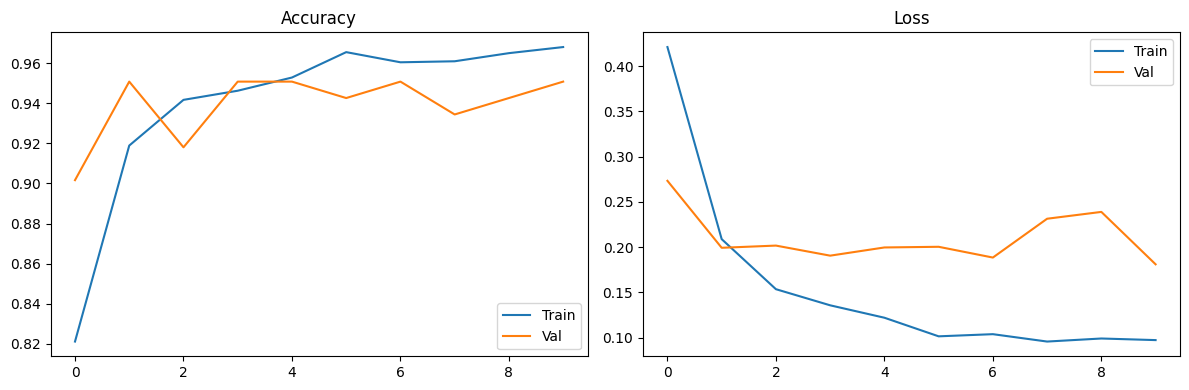

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_top.history["accuracy"],     label="Train")
axes[0].plot(history_top.history["val_accuracy"], label="Val")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(history_top.history["loss"],     label="Train")
axes[1].plot(history_top.history["val_loss"], label="Val")
axes[1].set_title("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=LABELS))

              precision    recall  f1-score   support

     not_pcb       0.97      0.97      0.97       240
         pcb       0.93      0.94      0.93       111

    accuracy                           0.96       351
   macro avg       0.95      0.95      0.95       351
weighted avg       0.96      0.96      0.96       351



# Evaluate Metrics

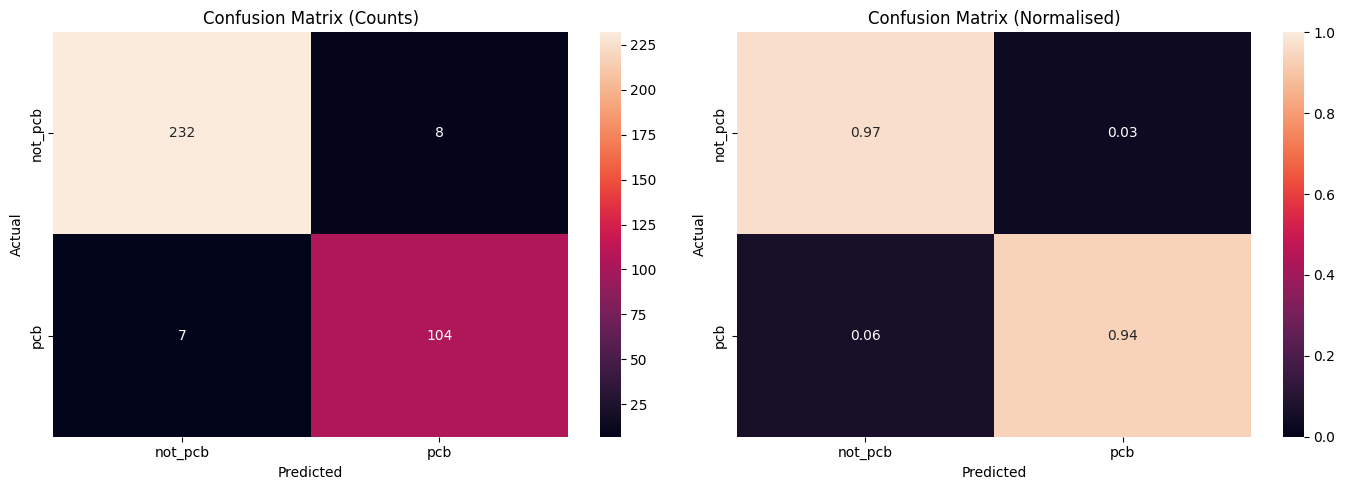

In [13]:


cm = confusion_matrix(y_true, y_pred)

# Normalise by row (actual class)
cm_normalised = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['not_pcb', 'pcb'],
            yticklabels=['not_pcb', 'pcb'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Take into account and show normaliztion table
sns.heatmap(cm_normalised, annot=True, fmt='.2f',
            xticklabels=['not_pcb', 'pcb'],
            yticklabels=['not_pcb', 'pcb'],
            vmin=0, vmax=1,
            ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalised)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix_both.png', dpi=150)
plt.show()

## 10. Convert to INT8 TFLite



In [15]:
def representative_dataset():
    for images, _ in train_ds.take(100):
        for img in images:
            
            yield [tf.expand_dims(img, 0)] # Images are raw [0, 255] float32 repr

converter = lite.TFLiteConverter.from_keras_model(model)
converter._experimental_disable_per_channel_quantization_for_dense_layers = True
converter.optimizations = [lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

with open("trained.tflite", "wb") as f:
    f.write(tflite_model)

print(f"TFLite model size: {len(tflite_model) / 1024:.1f} KB")

INFO:tensorflow:Assets written to: /tmp/tmp1siuraio/assets


INFO:tensorflow:Assets written to: /tmp/tmp1siuraio/assets


Saved artifact at '/tmp/tmp1siuraio'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  140616630035536: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  140616630035920: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  140616633048656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140616633050384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140616633051344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140616633052112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140616633052688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140616633050960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140616633053840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140616633054032: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1775141133.080321      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1775141133.080361      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


TFLite model size: 4786.3 KB


## 11. Verify Model Loads (Sanity Check)

In [16]:
import tensorflow as tf

interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input:",  input_details[0]["shape"],  "dtype:", input_details[0]["dtype"])
print("Output:", output_details[0]["shape"], "dtype:", output_details[0]["dtype"])

# Tensor arena estimate
details = interpreter.get_tensor_details()
total = sum(
    abs(np.prod(t["shape"])) * np.dtype(t["dtype"]).itemsize
    for t in details
)
print(f"Estimated tensor arena: {total / 1024:.1f} KB")
print(f"File size: {os.path.getsize('trained.tflite') / 1024:.1f} KB")
print("allocate_tensors() passed — model should load on OpenMV")

Input: [ 1 96 96  3] dtype: <class 'numpy.int8'>
Output: [1 2] dtype: <class 'numpy.int8'>
Estimated tensor arena: 8026.3 KB
File size: 4786.3 KB
allocate_tensors() passed — model should load on OpenMV


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


# Evaluate INT8 TFLite Model on Test Set


In [17]:

input_scale,  input_zero  = input_details[0]['quantization']
output_scale, output_zero = output_details[0]['quantization']

y_true_tflite = []
y_pred_tflite = []

for images, labels in test_ds:
    for img, label in zip(images.numpy(), labels.numpy()):
        # Quantise input: float32 → int8
        img_q = np.round(img / input_scale + input_zero).astype(np.int8)
        img_q = np.expand_dims(img_q, axis=0)  # (1, 96, 96, 3)

        interpreter.set_tensor(input_details[0]['index'], img_q)
        interpreter.invoke()

        # Dequantizing output
        output_q = interpreter.get_tensor(output_details[0]['index'])[0]
        output_f = (output_q.astype(np.float32) - output_zero) * output_scale

        y_true_tflite.append(np.argmax(label))
        y_pred_tflite.append(np.argmax(output_f))

y_true_tflite = np.array(y_true_tflite)
y_pred_tflite = np.array(y_pred_tflite)

tflite_acc = np.mean(y_true_tflite == y_pred_tflite)
print(f"TFLite INT8 Test Accuracy: {tflite_acc:.2%}")
print()
print(classification_report(y_true_tflite, y_pred_tflite, target_names=LABELS))

TFLite INT8 Test Accuracy: 94.59%

              precision    recall  f1-score   support

     not_pcb       0.97      0.95      0.96       240
         pcb       0.90      0.94      0.92       111

    accuracy                           0.95       351
   macro avg       0.93      0.94      0.94       351
weighted avg       0.95      0.95      0.95       351



## 12. Generate labels.txt

Required alongside `trained.tflite` on the OpenMV drive.

In [25]:
with open("labels.txt", "w") as f:
    f.write("\n".join(LABELS))

print("labels.txt contents:")
print(open("labels.txt").read())

labels.txt contents:
not_pcb
pcb


## 13. Download Files

Copy `trained.tflite` and `labels.txt` to your OpenMV drive.

In [19]:
print("Files ready to download:")
for file_name in ["trained.tflite", "labels.txt"]:
    size = os.path.getsize(file_name)
    print(f"  {file_name}: {size / 1024:.1f} KB")


Files ready to download:
  trained.tflite: 4786.3 KB
  labels.txt: 0.0 KB
